In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
#from sklearn.datasets import make_classification
from cuml.linear_model import LogisticRegression
#model = LogisticRegression()
import cudf

from sklearn.model_selection import StratifiedKFold,StratifiedGroupKFold,StratifiedShuffleSplit
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import accuracy_score,confusion_matrix,classification_report
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_curve 
from sklearn.metrics import roc_auc_score 
from sklearn.metrics import fbeta_score

#from sklearn.datasets import make_classification

****wit respect to tthe accracy  and 80/20 and 75/25  split** **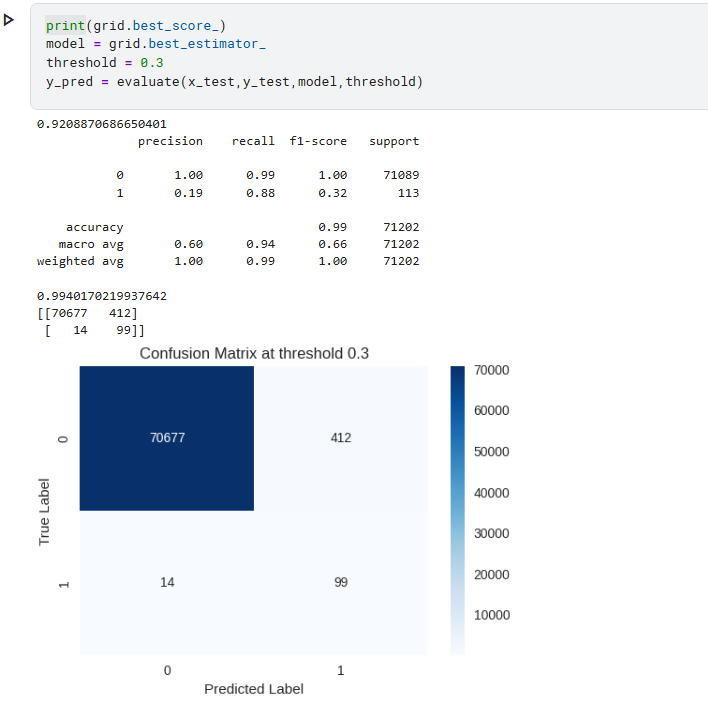

In [2]:
df = pd.read_csv("/kaggle/input/datasets/organizations/mlg-ulb/creditcardfraud/creditcard.csv")


**wrt recall as scoring  .. with 80/20 and 75/25 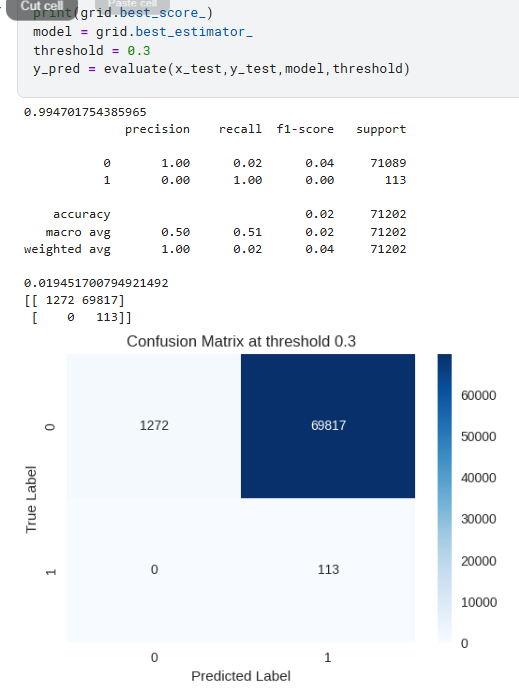**

In [3]:
def load_data(path):
  df = pd.read_csv(path)
  #df_test = pd.read_csv("credit_test.csv")
  df = df.drop(['Time'],axis=1)
  #df_test = df_test.drop(['Time'],axis=1)
  return df

def visualise(df):
  sns.countplot(x="Class", data=df)
  print(df.shape)
  print("\n")
  print(df.isnull().sum())
  plt.style.use('seaborn-v0_8')
  df.hist(bins=50,figsize=(20,14))
  plt.show()


def trainsplit(df,test_size):
  df = df.drop('Time',axis = 1)
  x=df.drop('Class',axis=1)
  y=df['Class']
  x_train,x_test, y_train,y_test = train_test_split(
x,y, test_size=test_size, random_state=42)
  print(y_train.value_counts())
  return x_train,x_test,y_train,y_test


def undersample(x_train,y_train):
    
    x_train = x_train.reset_index(drop=True)
    y_train = y_train.reset_index(drop=True).squeeze()
    train_df = pd.concat([x_train, y_train], axis=1)
    #print(y_train.name)
    fraud = train_df[train_df.Class == 1]
    normal = train_df[train_df.Class == 0]

    normal_sample = normal.sample(len(fraud), random_state=42)

    df_under = pd.concat([fraud, normal_sample])

    X_under = df_under.drop("Class", axis=1)
    y_under = df_under["Class"]
    train_df_undersampled = pd.concat([X_under, y_under], axis=1)
    
    return X_under, y_under,train_df_undersampled

def trainmodel(x_train,y_train):
  #from sklearn.linear_model import LogisticRegression
  from cuml.linear_model import LogisticRegression
  #model = LogisticRegression()
  model = LogisticRegression(max_iter=1000)
  model.fit(x_train,y_train)
  #y_pred = log_reg_undersampled.predict(x_undersampled_test)
  
  log_reg_undersampled.predict_proba(x_undersampled_test)
  return log_reg_undersampled

def evaluate(x_test,y_test,model,threshold):

  y_prob = model.predict_proba(x_test).iloc[:,1]              
  #threshold = 0.3 
  y_pred = (y_prob > threshold).astype(int)                                  #filtering the y_pred with a particular probbbb
  print(classification_report(y_test, y_pred))
  
  score = accuracy_score(y_test,y_pred)
  print(score)
  cm = confusion_matrix(y_test,y_pred)
  print(cm)
  plt.figure(figsize=(6,4))
  sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")

  plt.xlabel("Predicted Label")
  plt.ylabel("True Label")
  plt.title("Confusion Matrix at threshold "+ str(threshold))
  plt.show()
  print(classification_report(y_test,y_pred))
  return y_pred


def oversample(x_train,y_train):
    oversample = SMOTE()
    #f = train_sample.drop(['Time','Class'],axis = 1)     # i am forget that i already removed the time in the train_test_split 
    #target = df['Class'] 
    x_resampled,y_resampled = oversample.fit_resample(x_train,y_train)
    print(x_resampled.shape)
    print(y_resampled.shape)
    resampled = pd.concat([x_resampled, y_resampled], axis=1)                 # dont need this!! just made to visualise this!!!!!!!!
    sns.countplot(x="Class", data=resampled)
    return x_resampled,y_resampled,resampled
    

"""def hyperparatune(params)
  model = LogisticRegression(max_iter=1000)
  penalty = ['l1','l2',None]
  regularisation_strength = [100.0,10.0,0.1,0.2,0.3,0.01]
  solver = ['newton-cg','lbfgs','liblinear','sag','saga']
  class_weight = [{0:w;1:y} for w in [10,100,1000,10000,100000,1000000] for y in [10,100,1000,10000,1000000]]
  #cross_valid = [StratifiedKFold(),StratifiedGroupKFold(),StratifiedShuffleSplit()]
  parameters = dict(penalty=penalty,C=regularisation_strength,solver=solver,class_weight=class_weight)
  grid = GridSearchCV(estimator=model,param_grid=parameters,cv=StratifiedKFold(),scoring= 'recall',verbose=1,n_jobs=-1)

"""





"def hyperparatune(params)\n  model = LogisticRegression(max_iter=1000)\n  penalty = ['l1','l2',None]\n  regularisation_strength = [100.0,10.0,0.1,0.2,0.3,0.01]\n  solver = ['newton-cg','lbfgs','liblinear','sag','saga']\n  class_weight = [{0:w;1:y} for w in [10,100,1000,10000,100000,1000000] for y in [10,100,1000,10000,1000000]]\n  #cross_valid = [StratifiedKFold(),StratifiedGroupKFold(),StratifiedShuffleSplit()]\n  parameters = dict(penalty=penalty,C=regularisation_strength,solver=solver,class_weight=class_weight)\n  grid = GridSearchCV(estimator=model,param_grid=parameters,cv=StratifiedKFold(),scoring= 'recall',verbose=1,n_jobs=-1)\n\n"

(284807, 31)


Time      0
V1        0
V2        0
V3        0
V4        0
V5        0
V6        0
V7        0
V8        0
V9        0
V10       0
V11       0
V12       0
V13       0
V14       0
V15       0
V16       0
V17       0
V18       0
V19       0
V20       0
V21       0
V22       0
V23       0
V24       0
V25       0
V26       0
V27       0
V28       0
Amount    0
Class     0
dtype: int64


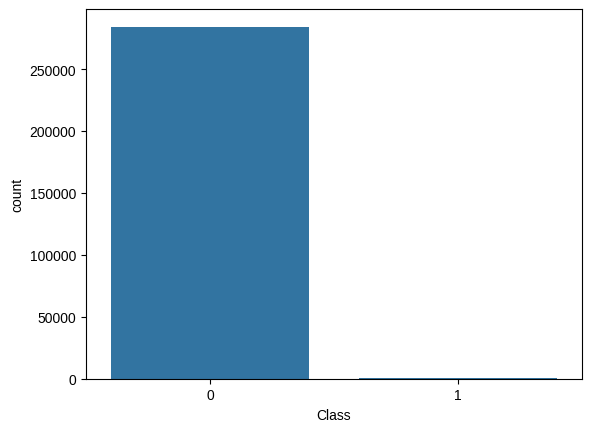

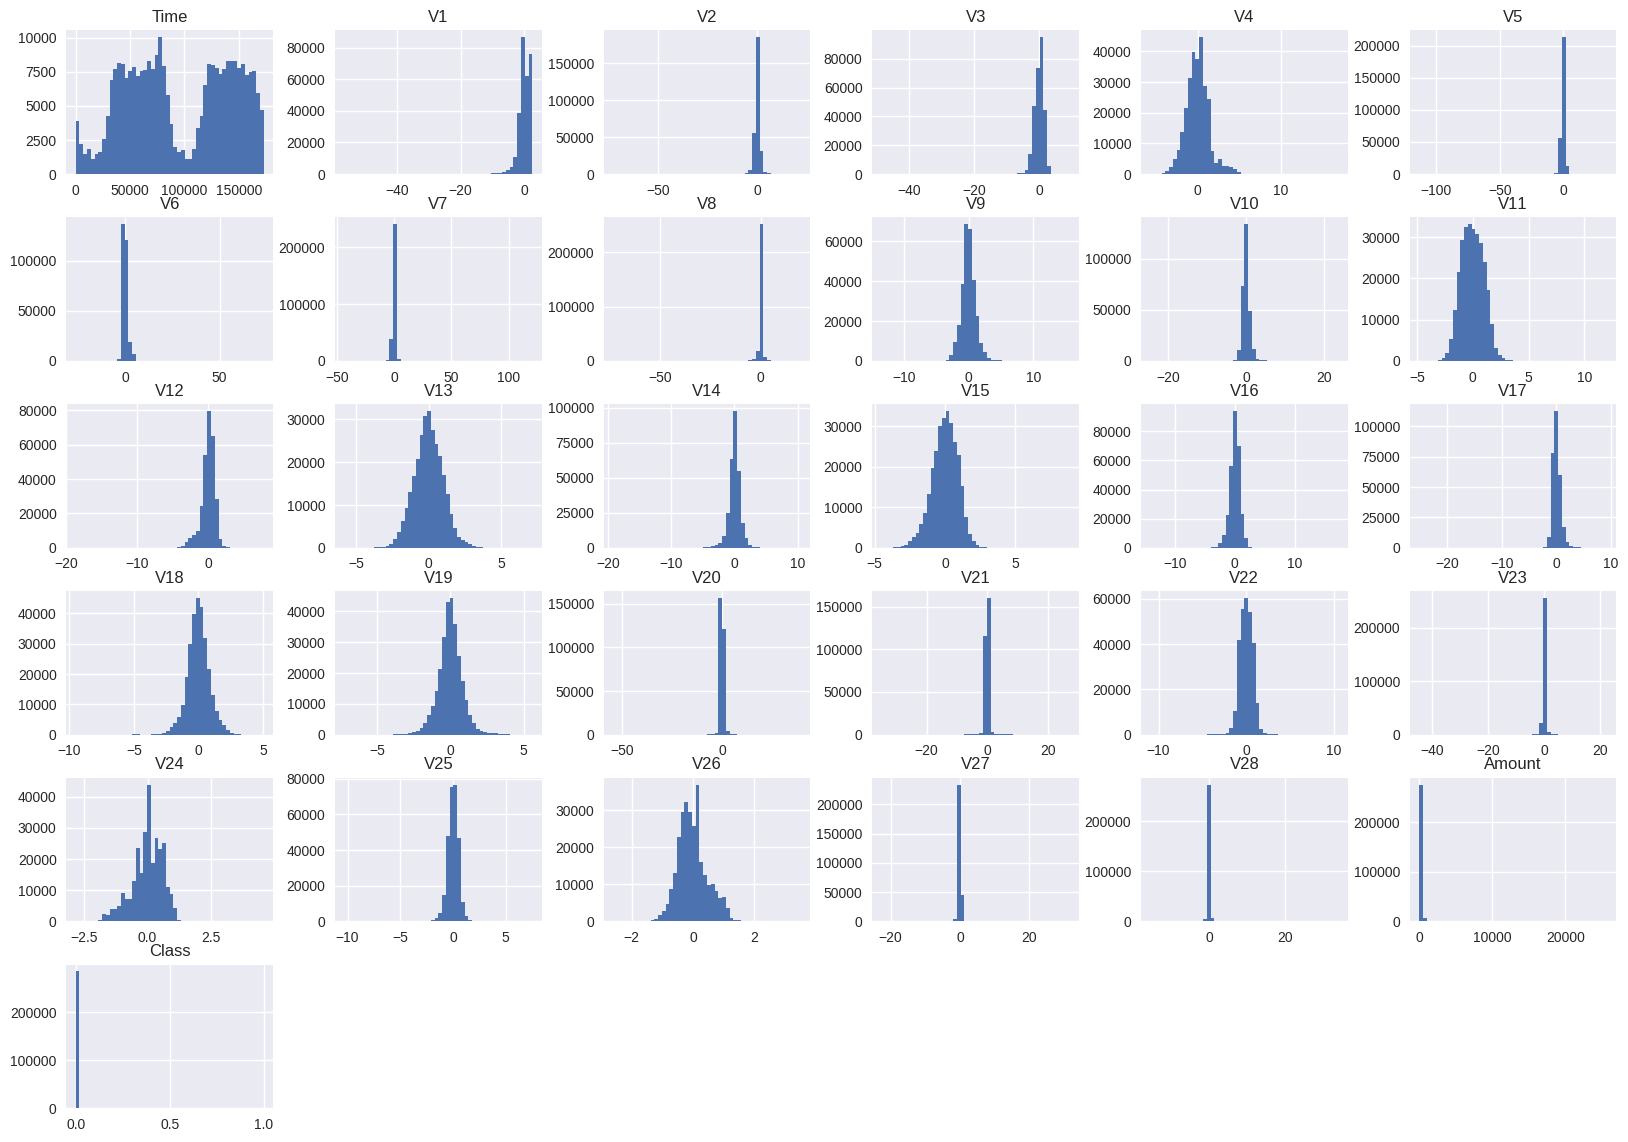

In [4]:
visualise(df)


In [5]:
test_size = 0.2 
x_train, x_test,y_train, y_test = trainsplit(df,test_size)


Class
0    227451
1       394
Name: count, dtype: int64


In [6]:
y_train

223361    0
165061    0
238186    0
150562    0
138452    0
         ..
119879    0
259178    0
131932    0
146867    0
121958    0
Name: Class, Length: 227845, dtype: int64

In [7]:
x_train_undersampled,y_train_undersampled,full = undersample(x_train,y_train)

(788, 30)


V1        0
V2        0
V3        0
V4        0
V5        0
V6        0
V7        0
V8        0
V9        0
V10       0
V11       0
V12       0
V13       0
V14       0
V15       0
V16       0
V17       0
V18       0
V19       0
V20       0
V21       0
V22       0
V23       0
V24       0
V25       0
V26       0
V27       0
V28       0
Amount    0
Class     0
dtype: int64


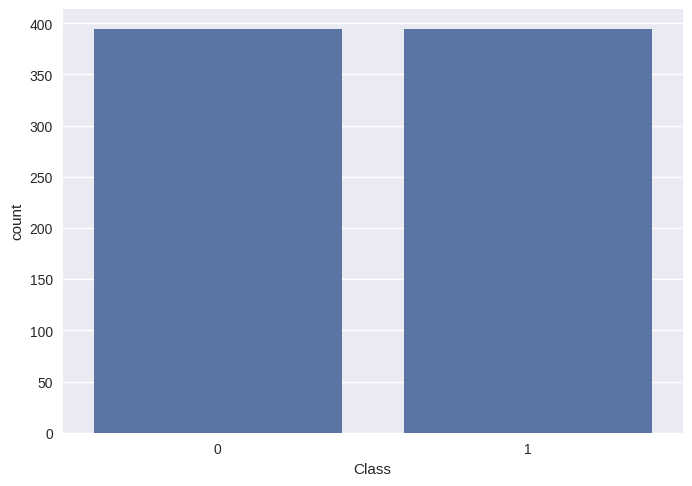

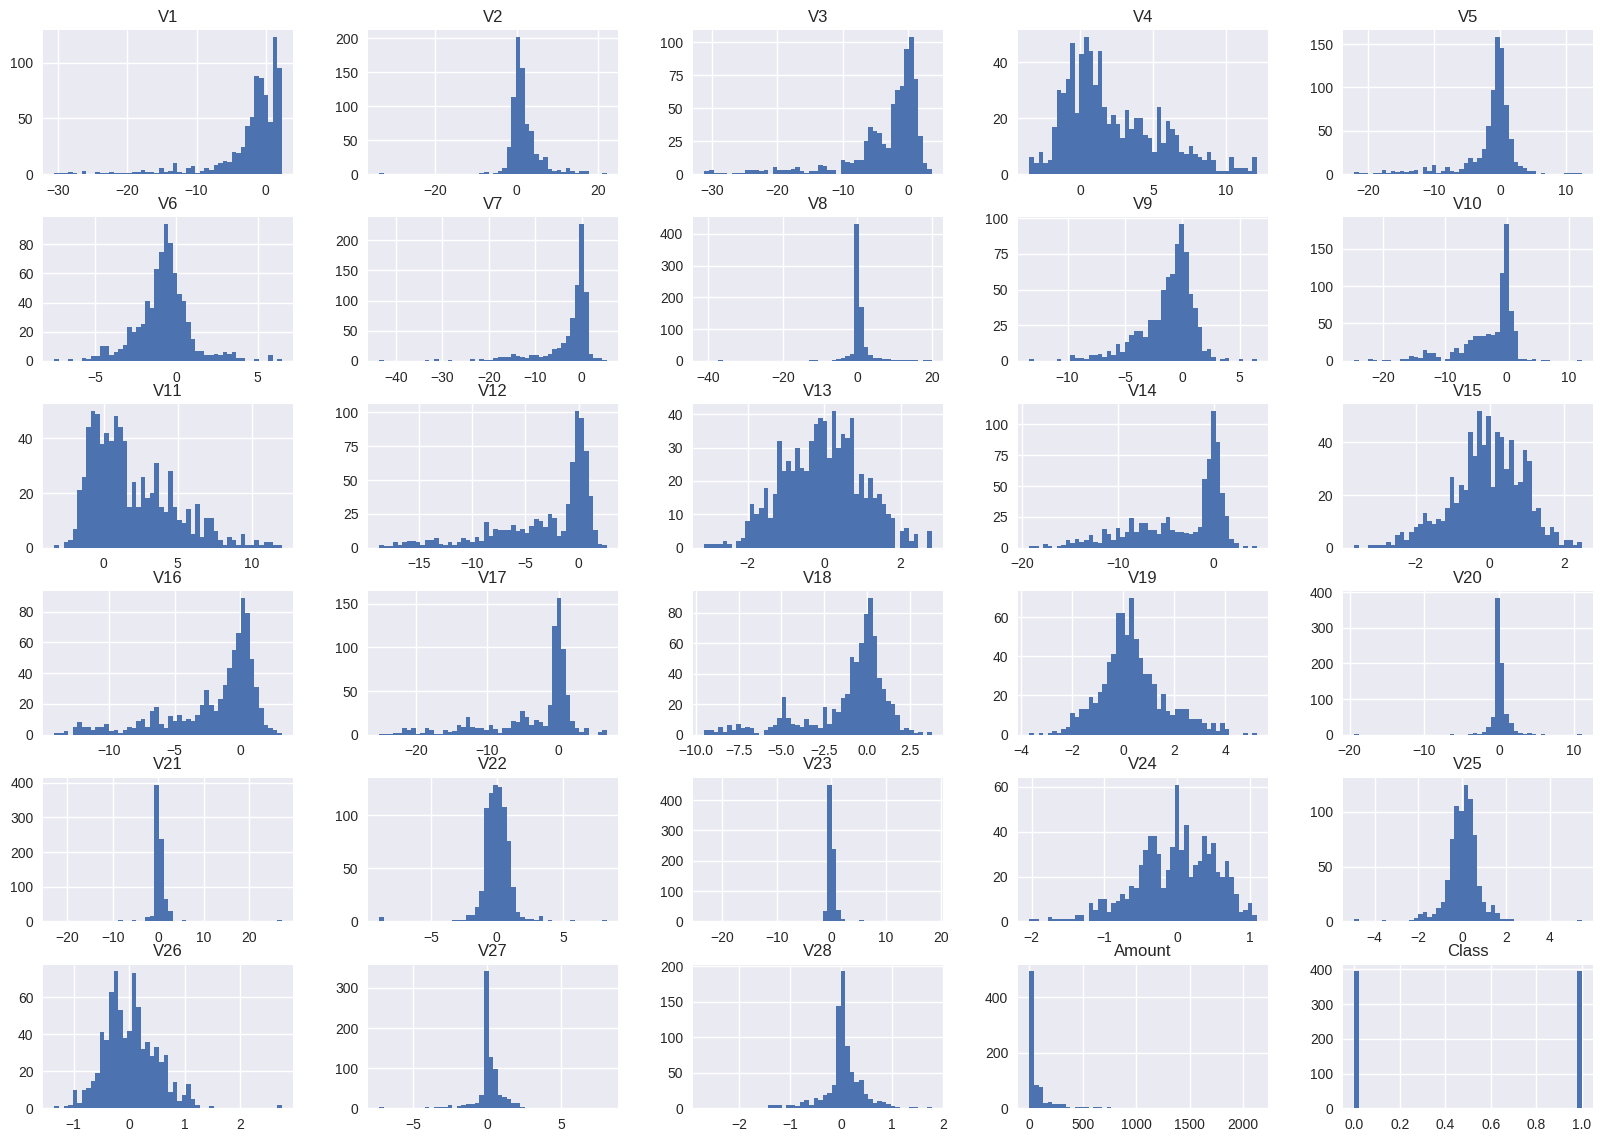

In [8]:
visualise(full)

Applying grid search!!!!!

In [9]:
  from cuml.linear_model import LogisticRegression
  model = LogisticRegression()
  #model.fit(df.drop(['Time','target'], axis=1), df['target'])
  model = LogisticRegression(max_iter=1000)
# trying to use the GPU
  penalty = ['l1','l2']
  regularisation_strength = [0.1,0.01]
  
  class_weight = [{0:w,1:y} for w in [100,10] for y in [100,10,587]]
  #cross_valid = [StratifiedKFold(),StratifiedGroupKFold(),StratifiedShuffleSplit()]
  parameters = dict(penalty=penalty,C=regularisation_strength,class_weight=class_weight)
  grid = GridSearchCV(estimator=model,param_grid=parameters,cv=StratifiedKFold(),scoring= 'recall',verbose=1,n_jobs=-1)
  grid.fit(x_train_undersampled,y_train_undersampled)
  print(grid.best_params_)
  grid.best_score_

Fitting 5 folds for each of 24 candidates, totalling 120 fits
[2026-03-30 09:43:19.886] [CUML] [warning] QWL-QN stopped, because the line search failed to advance (step delta = 0.000000)
{'C': 0.1, 'class_weight': {0: 10, 1: 587}, 'penalty': 'l1'}


np.float64(0.9974683544303797)

0.9974683544303797
              precision    recall  f1-score   support

           0       1.00      0.01      0.02     56864
           1       0.00      1.00      0.00        98

    accuracy                           0.01     56962
   macro avg       0.50      0.51      0.01     56962
weighted avg       1.00      0.01      0.02     56962

0.012991116884940838
[[  642 56222]
 [    0    98]]


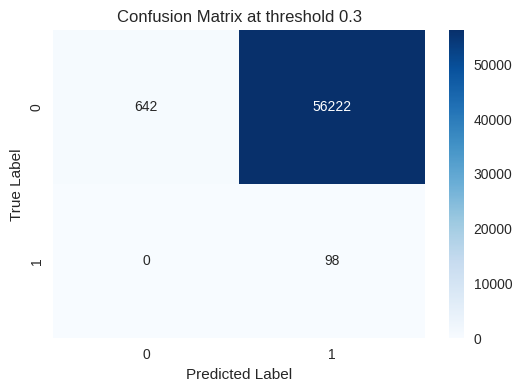

              precision    recall  f1-score   support

           0       1.00      0.01      0.02     56864
           1       0.00      1.00      0.00        98

    accuracy                           0.01     56962
   macro avg       0.50      0.51      0.01     56962
weighted avg       1.00      0.01      0.02     56962



In [10]:
print(grid.best_score_)
model = grid.best_estimator_
threshold = 0.3
y_pred = evaluate(x_test,y_test,model,threshold)

**NOW_WITH_0.25__TEST_split**

Class
0    213226
1       379
Name: count, dtype: int64
(758, 30)


V1        0
V2        0
V3        0
V4        0
V5        0
V6        0
V7        0
V8        0
V9        0
V10       0
V11       0
V12       0
V13       0
V14       0
V15       0
V16       0
V17       0
V18       0
V19       0
V20       0
V21       0
V22       0
V23       0
V24       0
V25       0
V26       0
V27       0
V28       0
Amount    0
Class     0
dtype: int64


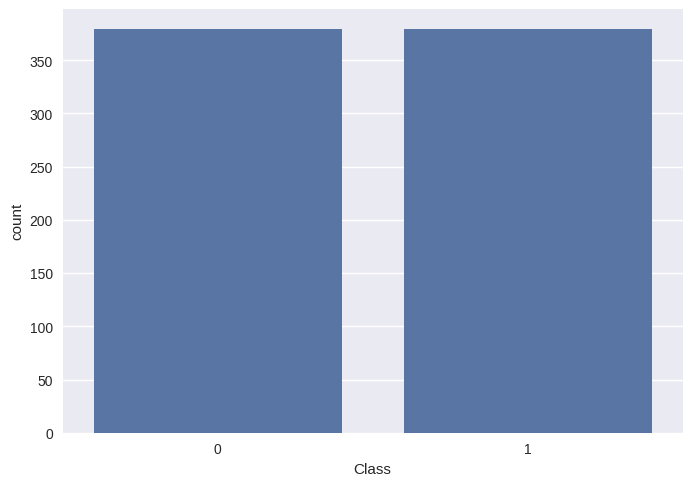

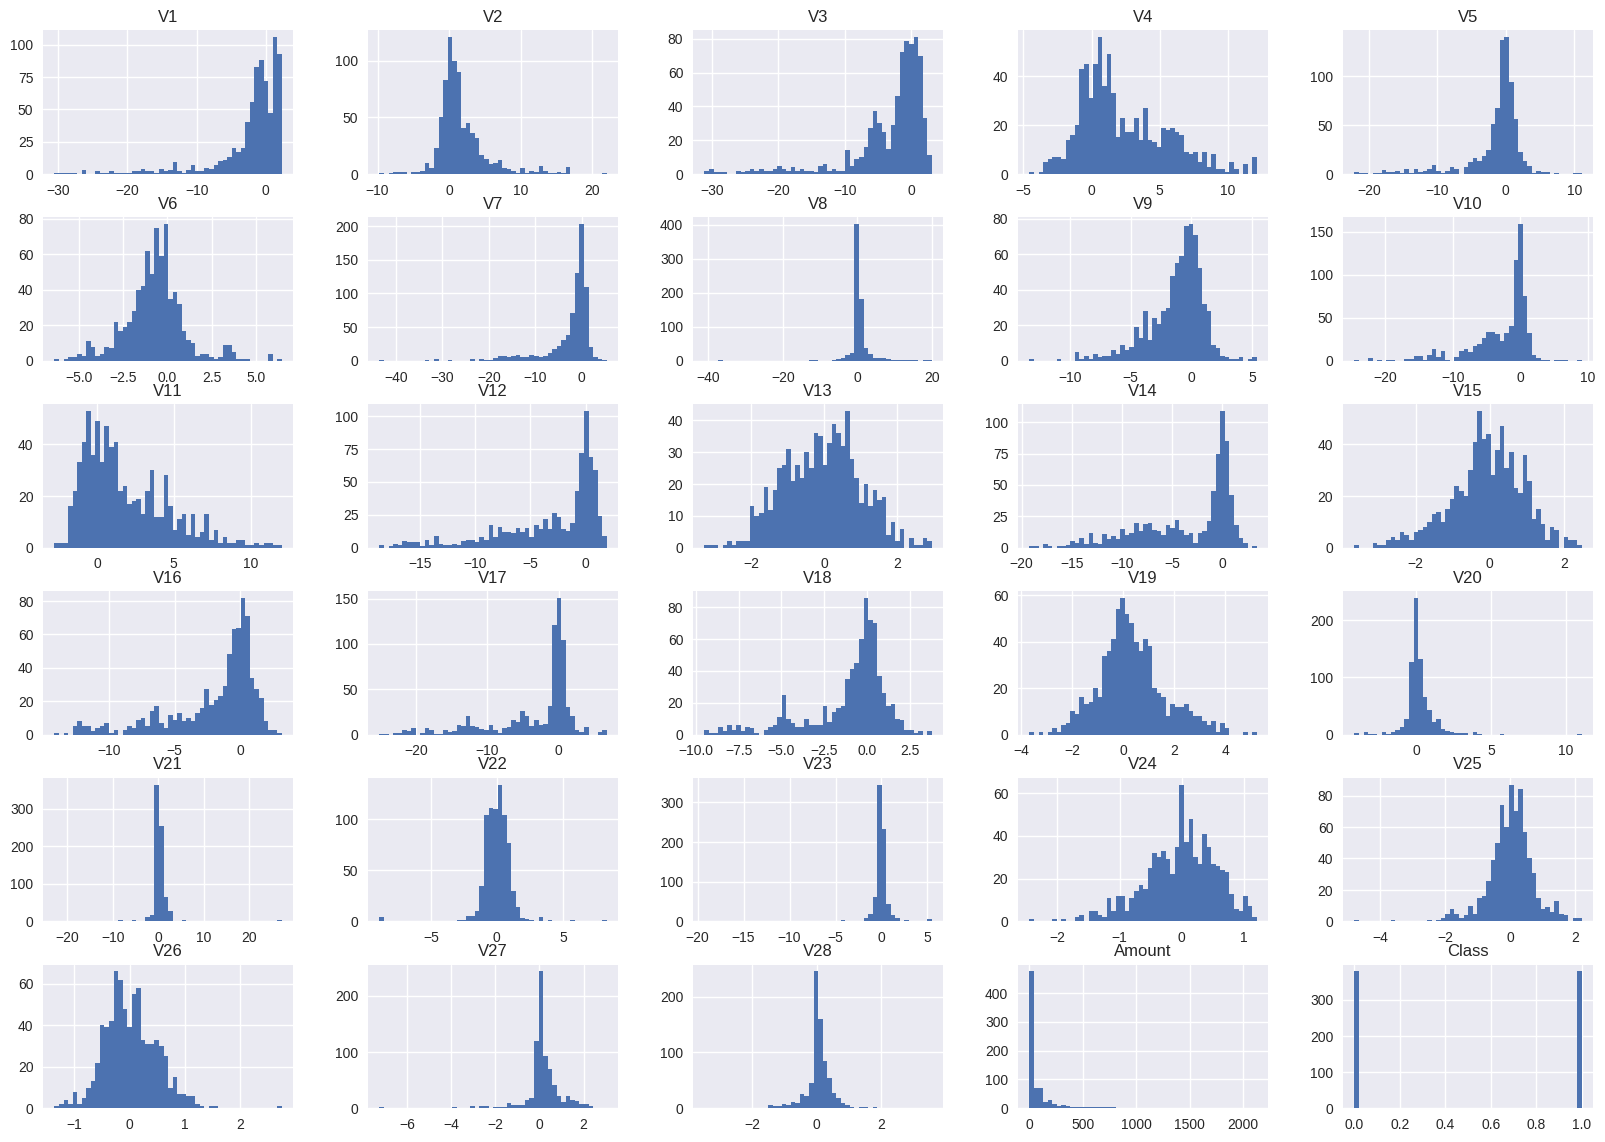

Fitting 5 folds for each of 24 candidates, totalling 120 fits
[2026-03-30 09:43:08.009] [CUML] [warning] QWL-QN stopped, because the line search failed to advance (step delta = 0.000000)
[2026-03-30 09:43:09.049] [CUML] [warning] QWL-QN stopped, because the line search failed to advance (step delta = 0.000000)
[2026-03-30 09:43:09.605] [CUML] [warning] L-BFGS stopped, because the line search failed to advance (step delta = 0.000000)
[2026-03-30 09:43:09.915] [CUML] [warning] QWL-QN stopped, because the line search failed to advance (step delta = 0.000000)
[2026-03-30 09:43:10.191] [CUML] [warning] L-BFGS stopped, because the line search failed to advance (step delta = 0.000000)
[2026-03-30 09:43:10.437] [CUML] [warning] QWL-QN stopped, because the line search failed to advance (step delta = 0.000000)
[2026-03-30 09:43:10.819] [CUML] [warning] QWL-QN stopped, because the line search failed to advance (step delta = 0.000000)
[2026-03-30 09:43:11.256] [CUML] [warning] L-BFGS stopped, beca

np.float64(0.9973684210526315)

In [11]:
  test_size = 0.25 
  x_train, x_test, y_train,y_test = trainsplit(df,test_size)
  x_train_undersampled,y_train_undersampled,full = undersample(x_train,y_train)
  visualise(full)
  from cuml.linear_model import LogisticRegression
  model = LogisticRegression()
  #model.fit(df.drop(['Time','target'], axis=1), df['target'])
  model = LogisticRegression(max_iter=1000)
  # trying to use the GPU
  penalty = ['l1','l2']
  regularisation_strength = [0.1,0.01]
  solver = ['liblinear','saga']
  class_weight = [{0:w,1:y} for w in [1] for y in [100,10,587]]
  #cross_valid = [StratifiedKFold(),StratifiedGroupKFold(),StratifiedShuffleSplit()]
  parameters = dict(penalty=penalty,C=regularisation_strength,solver=solver,class_weight=class_weight)
  grid = GridSearchCV(estimator=model,param_grid=parameters,cv=StratifiedKFold(),scoring= 'recall',verbose=1,n_jobs=-1)
  grid.fit(x_train_undersampled,y_train_undersampled)
  print(grid.best_params_)
  grid.best_score_

0.9973684210526315
              precision    recall  f1-score   support

           0       1.00      0.09      0.16     71089
           1       0.00      1.00      0.00       113

    accuracy                           0.09     71202
   macro avg       0.50      0.54      0.08     71202
weighted avg       1.00      0.09      0.16     71202

0.08890199713491194
[[ 6217 64872]
 [    0   113]]


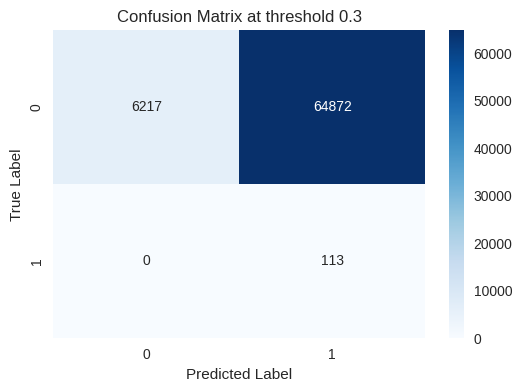

              precision    recall  f1-score   support

           0       1.00      0.09      0.16     71089
           1       0.00      1.00      0.00       113

    accuracy                           0.09     71202
   macro avg       0.50      0.54      0.08     71202
weighted avg       1.00      0.09      0.16     71202



In [12]:
print(grid.best_score_)
model = grid.best_estimator_
threshold = 0.3

y_pred = evaluate(x_test,y_test,model,threshold)

In [13]:
y_prob = model.predict_proba(x_test)#[:,1]## just the positve outcomes
y_prob = y_prob.iloc[:,1]
auc_score = roc_auc_score(y_test,y_prob)
print(auc_score)

0.9610392407274091


0.9610392407274091


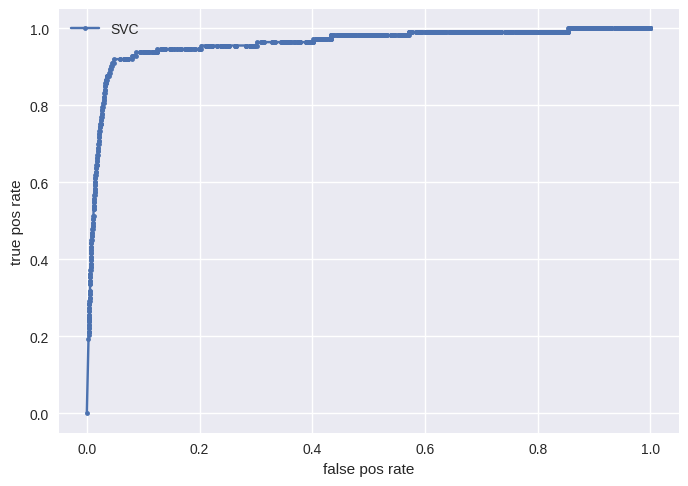

In [14]:
    auc_score = roc_auc_score(y_test,y_prob)
    print(auc_score)
    model_FPR, model_TPR,thresholds = roc_curve(y_test,y_prob) 
    plt.plot(model_FPR,model_TPR,marker = '.',label = 'SVC')
    plt.xlabel("false pos rate")
    plt.ylabel("true pos rate")
    plt.legend()
    plt.show()